[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Python-for-AI-Driven-Automation/blob/main/fast_track/15_time_series_and_forecasting.ipynb)

# 📓 Notebook 15 (fast track) — Time Series & Forecasting

> **Module:** Data Science · **Estimated time:** 60–75 min · **Difficulty:** Intermediate

> 🏎️ **You're on the fast track.** This is a **trimmed fast-track copy** of the canonical [`02_data_science/11_time_series_forecasting.ipynb`](../02_data_science/11_time_series_forecasting.ipynb). It keeps the essential arc — build a series, resample it, split it *in time*, baseline it, fit one real model, and backtest — and drops the deep dives (decomposition internals, the forecasting-library ecosystem tour, Stretch A/B, and the bonus report). For classical models (ARIMA / SARIMA / ETS) in depth, see the appendix [`A1_forecasting_classical.ipynb`](../02_data_science/A1_forecasting_classical.ipynb).

Forecasting is the first place where a habit you picked up everywhere else — *shuffle the data, then split* — turns **actively dangerous**. Time has a direction. A model is only useful if it predicts periods it has never seen, and those are always **future** periods. So one rule governs this entire notebook: **evaluate on a time-ordered hold-out, never a shuffled one.**

> 🧭 **Mental model.** A forecast is a **signal you decompose, then project.** Pull a series apart into **trend** (the slow drift) + **seasonality** (the repeating cycle) + **noise** (everything left), understand each piece, then extend them forward. And you only ever trust a forecast you have **backtested on a *time-ordered* hold-out** — train on the past, score on the future, never shuffle.

> 📎 **Prerequisites:** fast-track **NB 6** (pandas — `DataFrame`, `groupby`, indexing) and **NB 7** (visualization & stats — line plots, distributions, thinking in average error).

## 🎯 Learning objectives

By the end of this notebook you will be able to:

1. Explain **why time-series data is different** — order carries information, so you never shuffle it.
2. Build a **`DatetimeIndex`** series from trend + seasonality + noise, and plot it.
3. **Resample** (`.resample`) and **smooth** (`.rolling`) a series to move between time scales.
4. Make a **time-ordered train/test split**, and say precisely why `train_test_split(shuffle=True)` leaks the future.
5. Compute the two baselines every forecast must beat — **naive** and **seasonal-naive**.
6. Fit one real model — **Holt-Winters exponential smoothing** (trend + seasonality) — and forecast a hold-out.
7. **Backtest** with **MAE** and **MAPE**, and read a forecast-vs-actual plot with the split marked.

## 1. What makes a time series different

A time series is a sequence of values **stamped with a time and kept in order**: daily automation rate, hourly latency, monthly revenue. That ordering is not decoration — it *is* the signal. Yesterday's value is the best clue to today's; last Monday tells you about this Monday.

Two consequences follow, and they shape everything below:

- 🧠 **Order is information.** The gap between "row 5" and "row 6" *means* one day. Shuffle the rows and you destroy the very structure you are trying to model.
- ⚠️ **The future must never touch the past.** When you evaluate, every test point has to come **after** every training point — because in production the future genuinely has not happened yet. A shuffled split quietly mixes future days into training and hands you a score that is a **lie**.

Let's *see* that second point before we build anything real.

In [1]:
import numpy as np
import pandas as pd

# A tiny 14-day series that only ever goes UP.
demo_dates = pd.date_range("2024-01-01", periods=14, freq="D")
demo = pd.Series(np.linspace(0, 1, 14), index=demo_dates, name="value")

split = int(len(demo) * 0.8)                                     # 11 train / 3 test
train_ok, test_ok = demo.iloc[:split], demo.iloc[split:]        # RIGHT: cut the timeline once
train_bad = demo.sample(frac=1.0, random_state=0).iloc[:split]  # WRONG: shuffle, then take 80%

span = lambda s: f"{s.index.min().date()} to {s.index.max().date()}"
print("RIGHT (chronological)  train:", span(train_ok), "| test:", span(test_ok))
print("WRONG (shuffled)       train:", span(train_bad))

leaked = train_bad.index[train_bad.index > test_ok.index.min()]
print(f"\n  {len(leaked)} 'train' day(s) fall AFTER the test period begins ({test_ok.index.min().date()}).")
print("  The model would train on the future, then be 'tested' on the past. That is leakage.")

RIGHT (chronological)  train: 2024-01-01 to 2024-01-11 | test: 2024-01-12 to 2024-01-14
WRONG (shuffled)       train: 2024-01-02 to 2024-01-14

  1 'train' day(s) fall AFTER the test period begins (2024-01-12).
  The model would train on the future, then be 'tested' on the past. That is leakage.


## 2. A synthetic daily series — trend + seasonality + noise

We have no live bot here, so we **build** the series from the three pieces of the mental model. Knowing exactly what went in makes the rest satisfying: resampling should surface the trend, and a good model should recover the weekly cycle.

- **Trend:** a slow upward drift (the bot is improving).
- **Seasonality:** a weekly cycle (busier midweek) plus a mild yearly one.
- **Noise:** small day-to-day randomness, seeded so the notebook is reproducible.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 4)
rng = np.random.default_rng(42)               # seeded -> reproducible

n_days = 730                                  # two years of daily data
dates  = pd.date_range("2023-01-01", periods=n_days, freq="D")
t      = np.arange(n_days)

trend  = 0.50 + 0.0003 * t                            # slow upward drift
weekly = 0.05 * np.sin(2 * np.pi * t / 7)             # weekly cycle
yearly = 0.03 * np.sin(2 * np.pi * t / 365.25 - 1.5)  # mild yearly cycle
noise  = rng.normal(0, 0.015, n_days)                 # day-to-day randomness
auto_rate = (trend + weekly + yearly + noise).clip(0, 1)

df = pd.DataFrame({"date": dates, "auto_rate": auto_rate}).set_index("date")
print(df.head())
print(f"\nShape: {df.shape}   Range: {df.index.min().date()} to {df.index.max().date()}")

            auto_rate
date                 
2023-01-01   0.474646
2023-01-02   0.493908
2023-01-03   0.530769
2023-01-04   0.506927
2023-01-05   0.420532

Shape: (730, 1)   Range: 2023-01-01 to 2024-12-30


> 💡 **`pd.date_range` + `set_index`** turn a flat table into a *time-indexed* one — the move you make every time a CSV has a date column. A `DatetimeIndex` is what unlocks `.loc["2024-03"]`, `.resample`, and time-aware plotting.

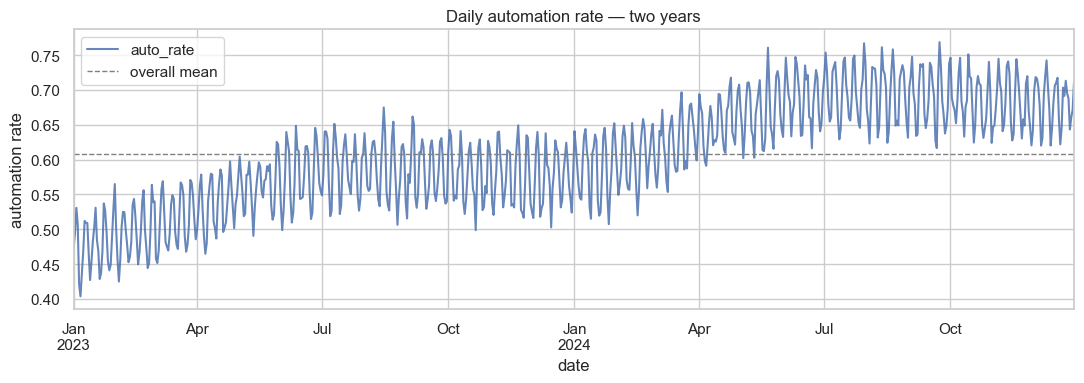

In [3]:
ax = df["auto_rate"].plot(color="#4C72B0", alpha=0.85,
                          title="Daily automation rate — two years", ylabel="automation rate")
ax.axhline(df["auto_rate"].mean(), color="grey", ls="--", lw=1, label="overall mean")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Resampling & rolling windows

The raw daily line is a jittery mess — noise drowns the trend. Two complementary cures:

- **`.resample(rule)`** — *change the time grid*: collapse days into weeks/months (`"W"`, `"ME"`). The time-series sibling of `groupby`. Fewer rows, clearer signal.
- **`.rolling(window)`** — *keep the grid*: replace each day with an aggregate of the surrounding `window` days. Still one row per day, but smoothed.

In [4]:
weekly_mean  = df["auto_rate"].resample("W").mean()    # daily -> weekly
monthly_mean = df["auto_rate"].resample("ME").mean()   # daily -> month-end

print(f"daily rows: {len(df)}   weekly rows: {len(weekly_mean)}   monthly rows: {len(monthly_mean)}")
print("\nFirst 3 monthly means:")
print(monthly_mean.head(3).round(3))

daily rows: 730   weekly rows: 106   monthly rows: 24

First 3 monthly means:
date
2023-01-31    0.481
2023-02-28    0.494
2023-03-31    0.513
Freq: ME, Name: auto_rate, dtype: float64


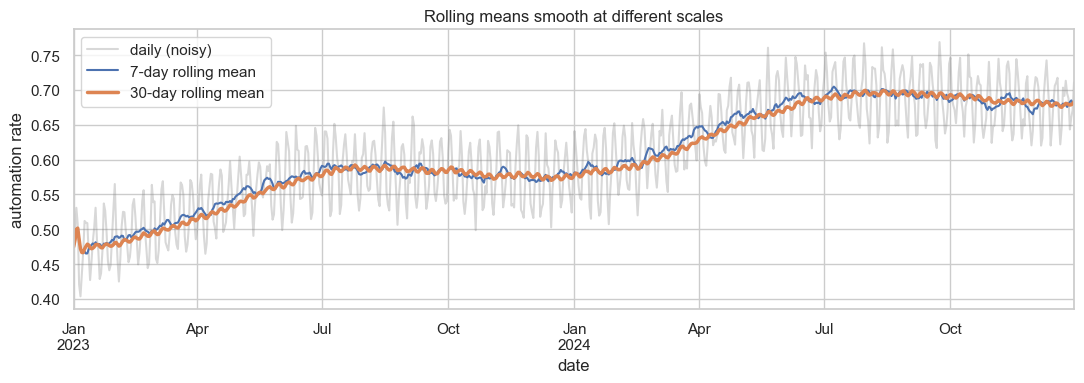

In [5]:
df["roll_7"]  = df["auto_rate"].rolling(window=7,  min_periods=1).mean()
df["roll_30"] = df["auto_rate"].rolling(window=30, min_periods=1).mean()

ax = df["auto_rate"].plot(alpha=0.30, color="grey", label="daily (noisy)")
df["roll_7"].plot(ax=ax, lw=1.5, label="7-day rolling mean")
df["roll_30"].plot(ax=ax, lw=2.5, label="30-day rolling mean")
ax.set(title="Rolling means smooth at different scales", ylabel="automation rate")
ax.legend()
plt.tight_layout()
plt.show()

---

### ✋ Quick exercise (~2 min) — A fortnightly (14-day) smoother

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

The 7-day and 30-day rolling means are already in `df`. Build a **14-day** rolling mean of `df["auto_rate"]` into a variable `roll_14`, and print its first three values.

```python
# .rolling(window=..., min_periods=1).mean() — a fortnight is 14 days
```

In [6]:
# ✍️ Your turn 👇
roll_14 = ...   # a 14-day rolling mean of df["auto_rate"]

<details>
<summary>✅ <b>Solution</b></summary>

```python
roll_14 = df["auto_rate"].rolling(window=14, min_periods=1).mean()
print(roll_14.head(3).round(3))
```

`window=14` averages each day with the previous 13; `min_periods=1` lets the window shrink at the very start so the first days are not `NaN`. A wider window is smoother but lags real changes more.
</details>

## 4. The time-ordered train/test split

Now we forecast, which means we need an honest test set. The rule from §1, made concrete: **hold out the *last* slice of time.** Train on the first 700 days; forecast the final 30. Every test day is strictly after every training day — exactly the situation you face in production.

> ⚠️ **Never `train_test_split(X, y, shuffle=True)` on a time series.** Its default `shuffle=True` scatters days at random, so future dates land in training and past dates land in test. The model gets to peek at the future, your error looks fantastic, then it collapses on real, forward-only data. For time series you slice by position (`.iloc[:cut]` / `.iloc[cut:]`) or pass `shuffle=False`.

In [7]:
train = df["auto_rate"].iloc[:700].asfreq("D")   # first 700 days
test  = df["auto_rate"].iloc[700:].asfreq("D")   # last 30 days  <- the future we must predict
h     = len(test)                                # forecast horizon

print(f"train: {len(train)} days ({train.index.min().date()} to {train.index.max().date()})")
print(f"test : {len(test)} days ({test.index.min().date()} to {test.index.max().date()})   horizon h = {h}")

train: 700 days (2023-01-01 to 2024-11-30)
test : 30 days (2024-12-01 to 2024-12-30)   horizon h = 30


How much does shuffling actually flatter you? Here is the same tiny model — a decision tree whose only feature is *"which day is it"* — scored both ways on a steeply trending series. A tree cannot extrapolate past its training range, so an honest future split exposes that weakness, while a shuffled split hides it by surrounding every test day with near-in-time neighbours.

In [8]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

rng_leak = np.random.default_rng(0)
N = 100
feature = np.arange(N).reshape(-1, 1)                          # the only feature: the day number
signal  = np.linspace(0, 20, N) + rng_leak.normal(0, 0.15, N)  # steep upward trend + noise
cut = 80

# RIGHT — time-ordered: train on days 0-79, score on the unseen future 80-99
mae_ordered = mean_absolute_error(
    signal[cut:],
    DecisionTreeRegressor(random_state=0).fit(feature[:cut], signal[:cut]).predict(feature[cut:]))

# WRONG — shuffle first, so future days leak into training
Xtr, Xte, ytr, yte = train_test_split(feature, signal, test_size=N - cut, shuffle=True, random_state=0)
mae_shuffled = mean_absolute_error(
    yte, DecisionTreeRegressor(random_state=0).fit(Xtr, ytr).predict(Xte))

print(f"time-ordered hold-out MAE : {mae_ordered:6.3f}   <- honest (must extrapolate the trend)")
print(f"shuffled     hold-out MAE : {mae_shuffled:6.3f}   <- flattering lie (future leaked in)")
print(f"\nShuffling looks ~{mae_ordered / mae_shuffled:.0f}x 'better'. In production the future is")
print("not available, so only the time-ordered number is real.")

time-ordered hold-out MAE :  1.816   <- honest (must extrapolate the trend)
shuffled     hold-out MAE :  0.209   <- flattering lie (future leaked in)

Shuffling looks ~9x 'better'. In production the future is
not available, so only the time-ordered number is real.


## 5. Baselines — naive & seasonal-naive

Never report a fancy model's error without a **baseline** beside it. If your neural net barely beats "tomorrow = today", the neural net is not the story. Two baselines you must always compute:

- **Naive:** repeat the last observed value across the whole horizon. Beats surprisingly much.
- **Seasonal-naive:** repeat the last *season*. For a weekly cycle, each forecast day copies the same weekday one week earlier — the right baseline whenever seasonality is real.

In [9]:
# Naive: carry the last training value forward
fc_naive = pd.Series(train.iloc[-1], index=test.index, name="naive")

# Seasonal-naive: tile the last 7 training days across the horizon (weekly season)
last_week = train.iloc[-7:].values
fc_snaive = pd.Series([last_week[i % 7] for i in range(h)], index=test.index, name="seasonal_naive")

print(f"naive          : constant {fc_naive.iloc[0]:.3f} for {h} days")
print(f"seasonal-naive : repeats the last 7 days {last_week.round(3)}")

naive          : constant 0.641 for 30 days
seasonal-naive : repeats the last 7 days [0.649 0.709 0.72  0.67  0.647 0.62  0.641]


---

### ✋ Quick exercise (~2 min) — A 7-day moving-average baseline

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

A third cheap baseline: carry the **mean of the last 7 training days** forward across the whole horizon. Build it into `fc_ma7` — a `Series` indexed by `test.index`.

```python
# train.tail(7).mean() gives the number; wrap it in a pd.Series over test.index
```

In [10]:
# ✍️ Your turn 👇
fc_ma7 = ...   # constant = mean of the last 7 train days, over test.index

<details>
<summary>✅ <b>Solution</b></summary>

```python
fc_ma7 = pd.Series(train.tail(7).mean(), index=test.index, name="ma7")
print(f"7-day moving-average baseline: constant {fc_ma7.iloc[0]:.3f} for {len(test)} days")
```

A moving-average baseline smooths the last week's noise into a single level, then extends it flat. It usually sits between the jumpy naive forecast and a seasonal one.
</details>

## 6. One real model — Holt-Winters

Baselines are flat; a real series has **trend and seasonality** a good model should ride. **Holt-Winters exponential smoothing** (a.k.a. triple exponential smoothing) is the classic first "real" forecaster: it tracks three moving pieces — **level**, **trend**, and a repeating **seasonal** component — and projects all three forward. It ships with `statsmodels`, needs no external data, and is a strong, honest baseline before you reach for anything heavier.

In [11]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Additive trend + additive weekly seasonality (period = 7 days)
hw_fit = ExponentialSmoothing(
    train, trend="add", seasonal="add", seasonal_periods=7,
    initialization_method="estimated",
).fit()
fc_hw = hw_fit.forecast(h)
fc_hw.name = "holt_winters"

print("fitted smoothing parameters:")
print(f"  alpha (level)  = {hw_fit.params['smoothing_level']:.3f}")
print(f"  beta  (trend)  = {hw_fit.params['smoothing_trend']:.3f}")
print(f"  gamma (season) = {hw_fit.params['smoothing_seasonal']:.3f}")

fitted smoothing parameters:
  alpha (level)  = 0.055
  beta  (trend)  = 0.055
  gamma (season) = 0.000


## 7. Backtest & evaluate — MAE & MAPE

The hold-out *is* our backtest: we trained only on the past, so scoring on the last 30 days simulates having forecast them for real. Two error metrics, both answering "how wrong, on average":

- **MAE** — mean absolute error: the average size of the miss, in the target's own units. Robust and easy to explain.
- **MAPE** — mean absolute *percentage* error: the miss as a % of the actual. Scale-free and great for stakeholders — but it explodes if any actual is near 0 (a trap we hit on purpose in the exercises).

Lower is better for both. We score every forecast against the same `test`.

In [12]:
def evaluate(y_true, y_pred, name):
    mae  = (y_true - y_pred).abs().mean()
    mape = ((y_true - y_pred).abs() / y_true.abs()).mean() * 100
    return {"model": name, "MAE": mae, "MAPE %": mape}

results = pd.DataFrame([
    evaluate(test, fc_naive,  "naive"),
    evaluate(test, fc_snaive, "seasonal_naive"),
    evaluate(test, fc_hw,     "Holt-Winters"),
]).set_index("model").sort_values("MAE").round(4)

print(results)
print(f"\nBest model by MAE: {results['MAE'].idxmin()}")

                   MAE  MAPE %
model                         
Holt-Winters    0.0132  1.9321
seasonal_naive  0.0202  2.9179
naive           0.0467  6.6702

Best model by MAE: Holt-Winters


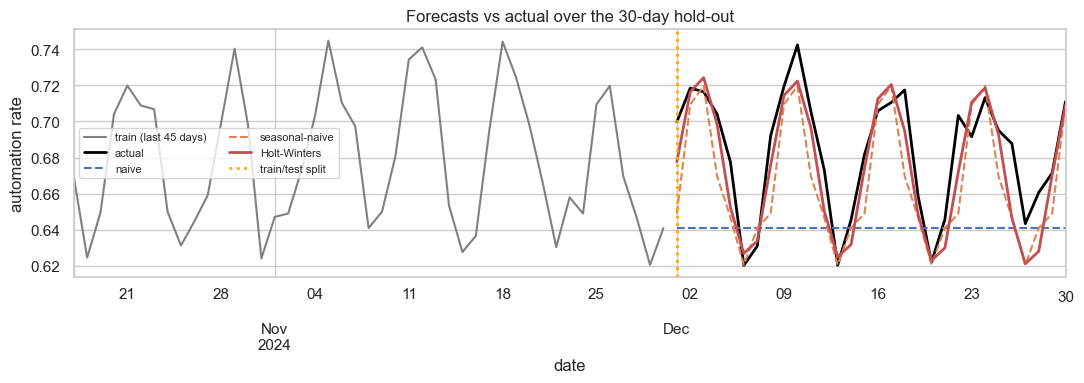

In [13]:
ax = train.tail(45).plot(color="grey", label="train (last 45 days)")
test.plot(ax=ax, color="black", lw=2, label="actual")
fc_naive.plot(ax=ax, ls="--", label="naive")
fc_snaive.plot(ax=ax, ls="--", label="seasonal-naive")
fc_hw.plot(ax=ax, lw=2, color="#C44E52", label="Holt-Winters")
ax.axvline(test.index[0], color="orange", ls=":", lw=2, label="train/test split")
ax.set(title="Forecasts vs actual over the 30-day hold-out", ylabel="automation rate")
ax.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

---

### ✋ Quick exercise (~2 min) — Quantify the win

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

The `results` table has each model's `MAE`. Compute how much **Holt-Winters** improves on the **naive** baseline, as a percentage reduction in MAE, into a variable `improvement`, and print it.

```python
# improvement = (1 - HW_MAE / naive_MAE) * 100 ; read cells with results.loc["<model>", "MAE"]
```

In [14]:
# ✍️ Your turn 👇
improvement = ...   # % reduction in MAE of Holt-Winters vs naive

<details>
<summary>✅ <b>Solution</b></summary>

```python
naive_mae = results.loc["naive", "MAE"]
hw_mae    = results.loc["Holt-Winters", "MAE"]
improvement = (1 - hw_mae / naive_mae) * 100
print(f"Holt-Winters cuts naive MAE from {naive_mae:.4f} to {hw_mae:.4f} — a {improvement:.1f}% improvement")
```

Always frame a model's value **relative to the baseline it must beat**. "MAE = 0.013" means nothing on its own; "a ~72% improvement over naive" is the number a stakeholder can act on.
</details>

## 8. Pitfalls to avoid

- ⚠️ **Leakage via shuffling.** The cardinal sin (§1, §4). Any random split — `train_test_split(shuffle=True)`, `KFold(shuffle=True)`, `cross_val_score`'s defaults — leaks the future on time-ordered data. Split by time, or use a time-series CV (`TimeSeriesSplit`, walk-forward).
- ⚠️ **Evaluating on the training range.** A model always looks good on days it was fitted on. "Fits the history beautifully" is not evidence; only performance on a held-out *future* window counts.
- ⚠️ **Ignoring seasonality.** If a weekly (or yearly) cycle is real, a model that cannot represent it — or a baseline that is not seasonal — loses systematically. Match the model's seasonal period to the data (`seasonal_periods=7` here).
- ⚠️ **MAPE near zero.** Percentage error blows up when actuals approach 0. Know your series; prefer MAE or a symmetric metric when zeros are possible.
- ⚠️ **No baseline.** A forecast reported without naive/seasonal-naive beside it is unfalsifiable. Always show what you beat.

## 🧪 Practice exercises

Work these against the `df`, `train`, `test`, and baseline forecasts already defined above. Try each before opening its solution.

### Exercise 1 — ⭐ Weekly seasonality by weekday

Group `df` by **day of the week** and print the mean `auto_rate` for each weekday (Monday → Sunday). Which weekday is busiest? This is the weekly cycle a seasonal model exists to capture.

In [15]:
# Your code here  👇

<details>
<summary>💡 <b>Solution</b></summary>

```python
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
by_dow = df.groupby(df.index.day_name())["auto_rate"].mean().reindex(order)
print(by_dow.round(3))
print("Busiest weekday:", by_dow.idxmax())
```

`df.index.day_name()` turns each timestamp into a weekday label; grouping on it collapses two years down to seven averages. `reindex(order)` forces calendar order instead of alphabetical.
</details>

### Exercise 2 — ⭐⭐ 30-day rolling volatility

Smoothing showed the *level*; risk lives in the *spread*. Compute the **30-day rolling standard deviation** of `df["auto_rate"]`, plot it, and print the date of peak volatility.

In [16]:
# Your code here  👇

<details>
<summary>💡 <b>Solution</b></summary>

```python
vol = df["auto_rate"].rolling(window=30).std()
ax = vol.plot(title="30-day rolling volatility", ylabel="std of auto_rate", figsize=(11, 3.2))
plt.tight_layout()
plt.show()
print("Most volatile 30-day window ends on:", vol.idxmax().date())
```

`.rolling(30).std()` is the same windowing idea as a rolling mean, applied to spread instead of level. Spikes flag unstable periods — often holidays or incidents — that a single global standard deviation would hide.
</details>

### Exercise 3 — ⭐⭐ Beat the naive baseline

Build a **recursive 14-day moving-average** forecast: predict each of the 30 test days as the mean of the previous 14 known values, then feed each prediction back in before predicting the next day. Compute its MAE and compare with the naive baseline (`fc_naive`).

In [17]:
# Your code here  👇

<details>
<summary>💡 <b>Solution</b></summary>

```python
history = list(train.values)
preds = []
for _ in range(len(test)):
    step = np.mean(history[-14:])   # mean of the last 14 known values
    preds.append(step)
    history.append(step)            # recursive: the prediction becomes "known"

fc_ma14 = pd.Series(preds, index=test.index, name="ma14")
mae_ma14  = (test - fc_ma14).abs().mean()
mae_naive = (test - fc_naive).abs().mean()
print(f"recursive 14-day MA MAE: {mae_ma14:.4f}   |   naive MAE: {mae_naive:.4f}")
print("Beats naive!" if mae_ma14 < mae_naive else "Does not beat naive here.")
```

Because we feed predictions back in, the forecast quickly relaxes to a flat level — like the naive/MA baselines it has **no trend or seasonality**, which is exactly why Holt-Winters can pull ahead.
</details>

### Exercise 4 — ⭐⭐ Debug me 🐞

The cell below computes **MAPE** on a small demand series and prints `inf%` instead of a real number. Find the bug, explain it in one line, then report a sensible error instead.

In [18]:
# 🐞 This MAPE returns inf. Why? Fix it in your solution below.
actual   = np.array([12.0, 0.0, 8.0, 5.0, 3.0])   # note the zero-demand day
forecast = np.array([10.0, 1.0, 9.0, 4.0, 3.0])

mape = np.mean(np.abs((actual - forecast) / actual)) * 100
print(f"MAPE = {mape:.1f}%")

MAPE = inf%


/var/folders/sz/1k1y5gg975j3mc23vxwrt0v40000gn/T/ipykernel_60077/1782350832.py:5: RuntimeWarning: divide by zero encountered in divide
  mape = np.mean(np.abs((actual - forecast) / actual)) * 100


<details>
<summary>💡 <b>Solution</b></summary>

```python
# Bug: MAPE divides by the actual value, and one actual is 0 -> divide by zero -> inf.
# MAPE is simply undefined when an actual can be zero. Two honest fixes:

mask = actual != 0                                   # (a) drop the zero-actual points
mape_safe = np.mean(np.abs((actual[mask] - forecast[mask]) / actual[mask])) * 100

denom = (np.abs(actual) + np.abs(forecast)) / 2      # (b) sMAPE never divides by 0 here
smape = np.mean(np.abs(actual - forecast) / denom) * 100

print(f"MAPE (zeros dropped) = {mape_safe:.1f}%   |   sMAPE = {smape:.1f}%")
```

The zero-demand day makes the percentage error infinite. When a series can hit zero, reach for **MAE** or a **symmetric** metric (sMAPE) instead of raw MAPE.
</details>

## 🧠 Stretch exercises

Two harder problems that go a step past the Practice set. The fast track keeps only Stretch **C** and **D** — the canonical notebook has more.

### Stretch exercise C — ⭐⭐⭐ MAPE vs sMAPE, side by side

Write two functions, `mape(y_true, y_pred)` and `smape(y_true, y_pred)`, then apply both to the **Holt-Winters** forecast (`fc_hw`) and the **naive** forecast (`fc_naive`) against `test`. When would you trust sMAPE more?

In [19]:
# Your code here  👇

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
def mape(y_true, y_pred):
    return (np.abs(y_true - y_pred) / np.abs(y_true)).mean() * 100

def smape(y_true, y_pred):
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2
    return (np.abs(y_true - y_pred) / denom).mean() * 100

for name, fc in [("Holt-Winters", fc_hw), ("naive", fc_naive)]:
    print(f"{name:>13}:  MAPE = {mape(test, fc):5.2f}%   sMAPE = {smape(test, fc):5.2f}%")
```

**Reasoning.** MAPE divides by the actual, so it **blows up as actuals approach 0** and it punishes over- and under-forecasts asymmetrically (the denominator differs). sMAPE divides by the *average* of actual and forecast, which is bounded and symmetric, so it stays finite and treats over/under errors even-handedly. Trust sMAPE more whenever the series can get close to zero, or when you need a metric that cannot be gamed by systematically under-forecasting; keep plain MAE when you just want an interpretable absolute error in the series' own units.
</details>

### Stretch exercise D — ⭐⭐⭐ Walk-forward backtest

One 30-day hold-out is a single noisy sample. Do a **walk-forward backtest**: refit Holt-Winters at several rolling origins (e.g. every 60 days, starting at day 400), forecast 30 days each time, collect the per-fold MAE, and report the mean and spread. Is the single-split number from §7 representative?

In [20]:
# Your code here  👇

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
from statsmodels.tsa.holtwinters import ExponentialSmoothing

def hw_forecast(tr, k):
    m = ExponentialSmoothing(tr, trend="add", seasonal="add",
                             seasonal_periods=7, initialization_method="estimated")
    return m.fit().forecast(k)

series = df["auto_rate"]
folds = []
for start in range(400, len(series) - 30, 60):        # rolling origins
    tr = series.iloc[:start].asfreq("D")
    te = series.iloc[start:start + 30]
    folds.append(np.abs(te.values - hw_forecast(tr, 30).values).mean())

folds = np.array(folds)
print(f"{len(folds)} folds — MAE mean {folds.mean():.4f}, "
      f"min {folds.min():.4f}, max {folds.max():.4f}")
```

**Reasoning.** A single split gives one number with no error bar; the model might have got lucky (or unlucky) on that particular month. Walk-forward refits at many origins and forecasts genuinely unseen windows each time, turning a point estimate into a **distribution** — a mean *and* a spread. That spread is the honest uncertainty of your error, it reveals whether the model is stable across regimes, and it is the only fair way to compare two models: a lower mean MAE paired with a much larger spread is not obviously the better choice.
</details>

## 🧠 Key takeaways

- **Order is the signal.** Time series carry information in their sequence — never shuffle, never `train_test_split(shuffle=True)`. Split by time.
- **Decompose, then project.** Every series is trend + seasonality + noise. Resample (`.resample`) to change the time grid; roll (`.rolling`) to smooth without losing rows.
- **Always beat a baseline.** Naive and seasonal-naive are cheap and surprisingly hard to beat — report them next to every "real" model.
- **Holt-Winters** is a strong, offline first model: it rides level + trend + a seasonal cycle, all from `statsmodels`.
- **Backtest on a time-ordered hold-out**, score with **MAE** (absolute, robust) and **MAPE** (percentage, but fragile near zero), and frame the result *relative to the baseline*.
- **A single split is one noisy sample.** Walk-forward backtesting turns it into a distribution — the honest way to compare models.

## ✅ Self-assessment

- [ ] Explain why shuffling a time series before splitting leaks the future
- [ ] Build a `DatetimeIndex` series and select by date
- [ ] Resample daily data to weekly/monthly and smooth it with a rolling window
- [ ] Make a time-ordered train/test split with `.iloc`
- [ ] Compute the naive and seasonal-naive baselines
- [ ] Fit a Holt-Winters model and forecast a hold-out horizon
- [ ] Evaluate a forecast with MAE and MAPE, and plot forecast vs actual with the split marked
- [ ] Say when MAPE breaks and what to use instead
- [ ] Describe what a walk-forward backtest adds over a single split

## 🚀 Next step

Continue with **Notebook 16 (fast track) — Model Evaluation & Feature Engineering**.

Want more depth on forecasting? The canonical **Module 2** goes further: [`02_data_science/11_time_series_forecasting.ipynb`](../02_data_science/11_time_series_forecasting.ipynb) adds decomposition, walk-forward tooling, and a tour of the forecasting library ecosystem, and the appendix [`A1_forecasting_classical.ipynb`](../02_data_science/A1_forecasting_classical.ipynb) covers ARIMA / SARIMA / ETS in full.